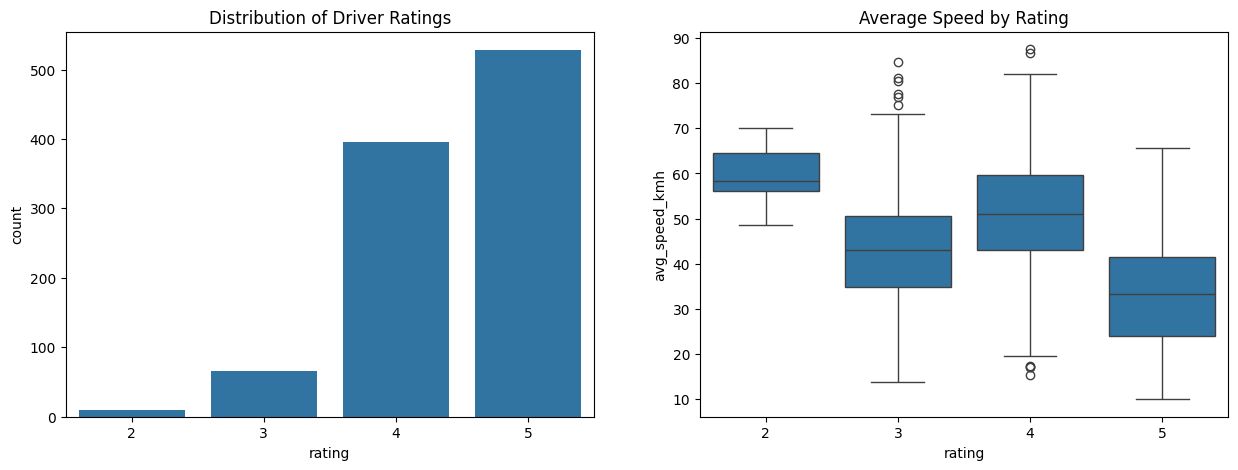

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/driver_feedback.csv")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='rating', ax=ax[0])
ax[0].set_title("Distribution of Driver Ratings")

sns.boxplot(data=df, x='rating', y='avg_speed_kmh', ax=ax[1])
ax[1].set_title("Average Speed by Rating")

plt.show()

In [4]:
driver_stats = df.groupby('driver_id').agg({
    'avg_speed_kmh': ['mean', 'max', 'std'],
    'hard_brake_event': 'sum',
    'rating': 'mean',
    'trip_id': 'count'
}).reset_index()

driver_stats.columns = [
    'driver_id', 'speed_mean', 'speed_max', 'speed_std', 
    'total_hard_brakes', 'avg_rating', 'total_trips'
]

driver_stats['risk_score'] = (driver_stats['speed_mean'] * 0.4) + (driver_stats['total_hard_brakes'] * 2.0)

driver_stats.head()

,driver_id,speed_mean,speed_max,speed_std,total_hard_brakes,avg_rating,total_trips,risk_score
0,D000,40.907170,86.573011,16.639075,1,4.666667,24,18.362868
1,D001,41.071998,76.986009,17.501424,2,4.380952,21,20.428799
2,D002,45.259697,76.200909,15.956465,4,4.272727,22,26.103879
3,D003,45.780245,74.469385,14.206527,0,4.500000,16,18.312098
4,D004,40.967547,62.515583,13.691386,2,4.434783,23,20.387019


In [22]:
driver_stats.to_csv("../data/driver_stats_summary.csv", index=False)
print("✅ Summary saved")

✅ Summary saved
